In [367]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from scipy.ndimage import label
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

# Autoencoder

In [368]:
import random as rng

def get_gaussian(mu,sigma):
    def gaussian(x):
        a = -1/2 * (x-mu)**2/sigma**2
        return np.exp(a)/(sigma*np.sqrt(2*np.pi))
    return np.vectorize(gaussian)
def get_ReLU(freq):
    def ReLU(x):
        return abs((x) * (x > 1-freq))
    return ReLU

class simulacra_dataset(Dataset):
    """simulacra of simulated data of neutrinos dataset."""

    def __init__(self, min_val, max_val, target_snr, length, seed, pusle_length):
        """
        Arguments:
            csv_file (string): Path to the csv file with annotations.
            root_dir (string): Directory with all the images.
            transform (callable, optional): Optional transform to be applied
                on a sample.
        """
        self.min_val = min_val
        self.max_val = max_val
        self.target_snr = target_snr
        self.length = length
        self.seed = seed
        self.pusle_length = pusle_length

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        np.random.seed(idx+self.seed)
        relu1 = get_ReLU(0.2)
        relu2 = get_ReLU(0.3)
        mu1 = rng.randint(self.min_val,self.max_val)
        sigma1 = rng.randint(10,30)
        mu2 = rng.randint(self.min_val,self.max_val)
        sigma2 = rng.randint(10,30)
        weight1 = relu1(rng.random())
        weight2 = relu2(rng.random())
        pulse = [get_gaussian(mu1,sigma1),get_gaussian(mu1+sigma1,sigma1),get_gaussian(mu2,sigma2)]

        mu, sigma = 0, 0.1 # mean and standard deviation
        s = np.random.normal(mu, sigma, self.pusle_length)
        a = np.linspace(0,self.pusle_length,self.pusle_length)
        clean = pulse[0](a) - pulse[1](a)*weight1 + pulse[2](a)*weight2
        snr = max(clean)/max(s)
        rand_num = rng.randint(-target_snr//2,target_snr//2)
        weight = (target_snr+rand_num)/snr
        res = clean*weight + s
        clean *= weight
        normalization_constant =  max(max(res),max(clean))
        return {
            "x": torch.from_numpy(res/normalization_constant).float().unsqueeze(0),
            "y": torch.from_numpy(clean/normalization_constant).float().unsqueeze(0),
        }

min_val, max_val, target_snr, length, seed, pusle_length = 20,200,100,1000,0,200
train_ds = simulacra_dataset(min_val, max_val, target_snr, length, seed, pusle_length)
length, seed = 100,1000
val_ds = simulacra_dataset(min_val, max_val, target_snr, length, seed, pusle_length)
length, seed = 100,2000
test_ds = simulacra_dataset(min_val, max_val, target_snr, length, seed, pusle_length)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

batch = next(iter(train_loader))
batch["x"].shape, batch["y"].shape

(torch.Size([64, 1, 200]), torch.Size([64, 1, 200]))

In [369]:
time_periods = 200
class autoencoder(nn.Module):
    def __init__(self, ):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size = 3, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv1d(16, 32, kernel_size = 5, stride=4, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv1d(32, 64, kernel_size = 9, stride=5, padding=1),
            nn.ReLU(inplace=True),

            nn.ConvTranspose1d(64, 32, kernel_size = 9, stride=5, padding=1, output_padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose1d(32, 16, kernel_size = 5, stride=4, padding=1, output_padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose1d(16, 1, kernel_size = 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(inplace=True),

            nn.ConvTranspose1d(1, 1, kernel_size = 3, stride=2, padding=1, output_padding=1),
            nn.Upsample(size=200, mode='linear', align_corners=False)
        )
    def forward(self, x):
        return self.net(x)

In [370]:
model = autoencoder().to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-4,
    weight_decay=1e-4,
)

model

autoencoder(
  (net): Sequential(
    (0): Conv1d(1, 16, kernel_size=(3,), stride=(2,), padding=(1,))
    (1): ReLU(inplace=True)
    (2): Conv1d(16, 32, kernel_size=(5,), stride=(4,), padding=(1,))
    (3): ReLU(inplace=True)
    (4): Conv1d(32, 64, kernel_size=(9,), stride=(5,), padding=(1,))
    (5): ReLU(inplace=True)
    (6): ConvTranspose1d(64, 32, kernel_size=(9,), stride=(5,), padding=(1,), output_padding=(1,))
    (7): ReLU(inplace=True)
    (8): ConvTranspose1d(32, 16, kernel_size=(5,), stride=(4,), padding=(1,), output_padding=(1,))
    (9): ReLU(inplace=True)
    (10): ConvTranspose1d(16, 1, kernel_size=(3,), stride=(2,), padding=(1,), output_padding=(1,))
    (11): ReLU(inplace=True)
    (12): ConvTranspose1d(1, 1, kernel_size=(3,), stride=(2,), padding=(1,), output_padding=(1,))
    (13): Upsample(size=200, mode=linear)
  )
)

In [371]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-2,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=10,
    min_lr=1e-6,
)

In [372]:
def run_epoch(loader, train=True, max_grad_norm=1.0):
    model.train() if train else model.eval()

    total_loss = 0.0
    skipped = 0

    for batch in loader:
        x = batch["x"].to(device)
        y = batch["y"].to(device)

        with torch.set_grad_enabled(train):
            y_hat = model(x)

            loss = F.smooth_l1_loss(y_hat, y)

            if not torch.isfinite(loss):
                skipped += 1
                continue

            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=max_grad_norm,
                )

                optimizer.step()

        total_loss += loss.item()

    n = max(1, len(loader) - skipped)

    return {
        "loss": total_loss / n,
        "skipped": skipped,
    }

In [373]:
num_epochs = 100

history = {
    "train_loss": [],
    "val_loss": [],
    "lr": [],
}

best_val = float("inf")
best_state = None
patience = 20
bad_epochs = 0

for epoch in range(1, num_epochs + 1):

    train_stats = run_epoch(
        train_loader,
        train=True,
        max_grad_norm=1.0,
    )

    val_stats = run_epoch(
        val_loader,
        train=False,
        max_grad_norm=1.0,
    )

    scheduler.step(val_stats["loss"])

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_stats["loss"])
    history["val_loss"].append(val_stats["loss"])
    history["lr"].append(current_lr)

    if val_stats["loss"] < best_val:
        best_val = val_stats["loss"]
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }
        bad_epochs = 0
    else:
        bad_epochs += 1

    print(
        f"Epoch {epoch:03d} | "
        f"lr {current_lr:.2e} | "
        f"train {train_stats['loss']:.6f} | "
        f"val {val_stats['loss']:.6f} | "
        f"skipped {train_stats['skipped']}"
    )

    if bad_epochs >= patience:
        print("Early stopping.")
        break

model.load_state_dict(best_state)
model.to(device)

Epoch 001 | lr 1.00e-02 | train 0.317402 | val 0.243096 | skipped 0
Epoch 002 | lr 1.00e-02 | train 0.228810 | val 0.183482 | skipped 0
Epoch 003 | lr 1.00e-02 | train 0.158304 | val 0.126144 | skipped 0
Epoch 004 | lr 1.00e-02 | train 0.110545 | val 0.098545 | skipped 0
Epoch 005 | lr 1.00e-02 | train 0.086907 | val 0.080596 | skipped 0
Epoch 006 | lr 1.00e-02 | train 0.074816 | val 0.067124 | skipped 0
Epoch 007 | lr 1.00e-02 | train 0.068020 | val 0.063470 | skipped 0
Epoch 008 | lr 1.00e-02 | train 0.066058 | val 0.066060 | skipped 0
Epoch 009 | lr 1.00e-02 | train 0.065603 | val 0.068009 | skipped 0
Epoch 010 | lr 1.00e-02 | train 0.065961 | val 0.065927 | skipped 0
Epoch 011 | lr 1.00e-02 | train 0.066230 | val 0.062142 | skipped 0
Epoch 012 | lr 1.00e-02 | train 0.065610 | val 0.064628 | skipped 0
Epoch 013 | lr 1.00e-02 | train 0.063693 | val 0.063156 | skipped 0
Epoch 014 | lr 1.00e-02 | train 0.066074 | val 0.063386 | skipped 0
Epoch 015 | lr 1.00e-02 | train 0.064773 | val 0

autoencoder(
  (net): Sequential(
    (0): Conv1d(1, 16, kernel_size=(3,), stride=(2,), padding=(1,))
    (1): ReLU(inplace=True)
    (2): Conv1d(16, 32, kernel_size=(5,), stride=(4,), padding=(1,))
    (3): ReLU(inplace=True)
    (4): Conv1d(32, 64, kernel_size=(9,), stride=(5,), padding=(1,))
    (5): ReLU(inplace=True)
    (6): ConvTranspose1d(64, 32, kernel_size=(9,), stride=(5,), padding=(1,), output_padding=(1,))
    (7): ReLU(inplace=True)
    (8): ConvTranspose1d(32, 16, kernel_size=(5,), stride=(4,), padding=(1,), output_padding=(1,))
    (9): ReLU(inplace=True)
    (10): ConvTranspose1d(16, 1, kernel_size=(3,), stride=(2,), padding=(1,), output_padding=(1,))
    (11): ReLU(inplace=True)
    (12): ConvTranspose1d(1, 1, kernel_size=(3,), stride=(2,), padding=(1,), output_padding=(1,))
    (13): Upsample(size=200, mode=linear)
  )
)

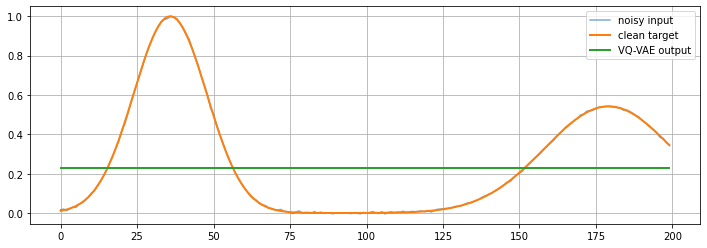

In [374]:
model.eval()

batch = next(iter(test_loader))

x = batch["x"].to(device)
y = batch["y"].to(device)

with torch.no_grad():
    y_hat = model(x)

idx = 0

noisy = x[idx, 0].cpu().numpy()
clean = y[idx, 0].cpu().numpy()
pred = y_hat[idx, 0].cpu().numpy()

plt.figure(figsize=(12, 4))
plt.plot(noisy, label="noisy input", alpha=0.6)
plt.plot(clean, label="clean target", linewidth=2)
plt.plot(pred, label="VQ-VAE output", linewidth=2)
plt.legend()
plt.grid(True)
plt.show()

In [375]:
breakpoint

<function breakpoint>

# ROI Finder

In [379]:
import random as rng

def get_gaussian(mu,sigma):
    def gaussian(x):
        a = -1/2 * (x-mu)**2/sigma**2
        return np.exp(a)/(sigma*np.sqrt(2*np.pi))
    return np.vectorize(gaussian)
def get_ReLU(freq):
    def ReLU(x):
        return abs((x) * (x > 1-freq))
    return ReLU

class simulacra_dataset(Dataset):
    """simulacra of simulated data of neutrinos dataset."""

    def __init__(self, min_val, max_val, target_snr, length, seed, pusle_length):
        """
        Arguments:
            csv_file (string): Path to the csv file with annotations.
            root_dir (string): Directory with all the images.
            transform (callable, optional): Optional transform to be applied
                on a sample.
        """
        self.min_val = min_val
        self.max_val = max_val
        self.target_snr = target_snr
        self.length = length
        self.seed = seed
        self.pusle_length = pusle_length

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        np.random.seed(idx+self.seed)
        relu1 = get_ReLU(0.2)
        relu2 = get_ReLU(0.3)
        mu1 = rng.randint(self.min_val,self.max_val)
        sigma1 = rng.randint(10,30)
        mu2 = rng.randint(self.min_val,self.max_val)
        sigma2 = rng.randint(10,30)
        weight1 = relu1(rng.random())
        weight2 = relu2(rng.random())
        pulse = [get_gaussian(mu1,sigma1),get_gaussian(mu1+sigma1,sigma1),get_gaussian(mu2,sigma2)]

        mu, sigma = 0, 0.1 # mean and standard deviation
        s = np.random.normal(mu, sigma, self.pusle_length)
        a = np.linspace(0,self.pusle_length,self.pusle_length)
        clean = pulse[0](a) - pulse[1](a)*weight1 + pulse[2](a)*weight2
        snr = max(clean)/max(s)
        rand_num = rng.randint(-target_snr//2,target_snr//2)
        weight = (target_snr+rand_num)/snr
        res = clean*weight + s
        clean *= weight
        normalization_constant =  max(max(res),max(clean))
        clean = clean/normalization_constant
        clean = (clean > 0.2)
        
        return {
            "x": torch.from_numpy(res/normalization_constant).float().unsqueeze(0),
            "y": torch.from_numpy(clean).float().unsqueeze(0),
        }

min_val, max_val, target_snr, length, seed, pusle_length = 20,500,100,1000,0,200
train_ds = simulacra_dataset(min_val, max_val, target_snr, length, seed, pusle_length)
length, seed = 100,1000
val_ds = simulacra_dataset(min_val, max_val, target_snr, length, seed, pusle_length)
length, seed = 100,2000
test_ds = simulacra_dataset(min_val, max_val, target_snr, length, seed, pusle_length)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

batch = next(iter(train_loader))
batch["x"].shape, batch["y"].shape

(torch.Size([64, 1, 200]), torch.Size([64, 1, 200]))

In [395]:
time_periods = 200
class disciminator(nn.Module):
    def __init__(self, ):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size = 3, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(16, 32, kernel_size = 5, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(p=0.1),

            nn.Conv1d(32, 64, kernel_size = 9, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.AdaptiveMaxPool1d(64),
            nn.Dropout(p=0.2),

            nn.Flatten(),
            nn.Linear(4096, 200),
            nn.Sigmoid()        
        )
    def forward(self, x):
        return self.net(x)

In [396]:
model = disciminator().to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-4,
    weight_decay=1e-4,
)

model

disciminator(
  (net): Sequential(
    (0): Conv1d(1, 16, kernel_size=(3,), stride=(2,), padding=(1,))
    (1): ReLU(inplace=True)
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(16, 32, kernel_size=(5,), stride=(2,), padding=(1,))
    (4): ReLU(inplace=True)
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Dropout(p=0.1, inplace=False)
    (7): Conv1d(32, 64, kernel_size=(9,), stride=(2,), padding=(1,))
    (8): ReLU(inplace=True)
    (9): AdaptiveMaxPool1d(output_size=64)
    (10): Dropout(p=0.2, inplace=False)
    (11): Flatten(start_dim=1, end_dim=-1)
    (12): Linear(in_features=4096, out_features=200, bias=True)
    (13): Sigmoid()
  )
)

In [397]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-2,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=10,
    min_lr=1e-6,
)

In [398]:
def run_epoch(loader, train=True, max_grad_norm=1.0):
    model.train() if train else model.eval()

    total_loss = 0.0
    skipped = 0

    for batch in loader:
        x = batch["x"].to(device)
        y = batch["y"].to(device)

        with torch.set_grad_enabled(train):
            y_hat = model(x)

            loss = F.mse_loss(y_hat, y)

            if not torch.isfinite(loss):
                skipped += 1
                continue

            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=max_grad_norm,
                )

                optimizer.step()

        total_loss += loss.item()

    n = max(1, len(loader) - skipped)

    return {
        "loss": total_loss / n,
        "skipped": skipped,
    }

In [399]:
num_epochs = 100

history = {
    "train_loss": [],
    "val_loss": [],
    "lr": [],
}

best_val = float("inf")
best_state = None
patience = 20
bad_epochs = 0

for epoch in range(1, num_epochs + 1):

    train_stats = run_epoch(
        train_loader,
        train=True,
        max_grad_norm=1.0,
    )

    val_stats = run_epoch(
        val_loader,
        train=False,
        max_grad_norm=1.0,
    )

    scheduler.step(val_stats["loss"])

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_stats["loss"])
    history["val_loss"].append(val_stats["loss"])
    history["lr"].append(current_lr)

    if val_stats["loss"] < best_val:
        best_val = val_stats["loss"]
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }
        bad_epochs = 0
    else:
        bad_epochs += 1

    print(
        f"Epoch {epoch:03d} | "
        f"lr {current_lr:.2e} | "
        f"train {train_stats['loss']:.6f} | "
        f"val {val_stats['loss']:.6f} | "
        f"skipped {train_stats['skipped']}"
    )

    if bad_epochs >= patience:
        print("Early stopping.")
        break

model.load_state_dict(best_state)
model.to(device)

/tmp/nix-shell-2754-2480905268/ipykernel_302624/4103826305.py:14: UserWarning: Using a target size (torch.Size([64, 1, 200])) that is different to the input size (torch.Size([64, 200])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(y_hat, y)
/tmp/nix-shell-2754-2480905268/ipykernel_302624/4103826305.py:14: UserWarning: Using a target size (torch.Size([40, 1, 200])) that is different to the input size (torch.Size([40, 200])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(y_hat, y)
/tmp/nix-shell-2754-2480905268/ipykernel_302624/4103826305.py:14: UserWarning: Using a target size (torch.Size([36, 1, 200])) that is different to the input size (torch.Size([36, 200])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(y_hat, y)


Epoch 001 | lr 1.00e-02 | train 0.156149 | val 0.142756 | skipped 0
Epoch 002 | lr 1.00e-02 | train 0.133735 | val 0.135931 | skipped 0
Epoch 003 | lr 1.00e-02 | train 0.142297 | val 0.131004 | skipped 0
Epoch 004 | lr 1.00e-02 | train 0.132422 | val 0.141247 | skipped 0
Epoch 005 | lr 1.00e-02 | train 0.139316 | val 0.128048 | skipped 0
Epoch 006 | lr 1.00e-02 | train 0.130855 | val 0.139858 | skipped 0
Epoch 007 | lr 1.00e-02 | train 0.139460 | val 0.127248 | skipped 0
Epoch 008 | lr 1.00e-02 | train 0.141974 | val 0.130524 | skipped 0
Epoch 009 | lr 1.00e-02 | train 0.136409 | val 0.136024 | skipped 0
Epoch 010 | lr 1.00e-02 | train 0.141649 | val 0.157209 | skipped 0
Epoch 011 | lr 1.00e-02 | train 0.132042 | val 0.139015 | skipped 0
Epoch 012 | lr 1.00e-02 | train 0.137209 | val 0.144777 | skipped 0
Epoch 013 | lr 1.00e-02 | train 0.134718 | val 0.136647 | skipped 0
Epoch 014 | lr 1.00e-02 | train 0.139138 | val 0.123972 | skipped 0
Epoch 015 | lr 1.00e-02 | train 0.141758 | val 0

disciminator(
  (net): Sequential(
    (0): Conv1d(1, 16, kernel_size=(3,), stride=(2,), padding=(1,))
    (1): ReLU(inplace=True)
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(16, 32, kernel_size=(5,), stride=(2,), padding=(1,))
    (4): ReLU(inplace=True)
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Dropout(p=0.1, inplace=False)
    (7): Conv1d(32, 64, kernel_size=(9,), stride=(2,), padding=(1,))
    (8): ReLU(inplace=True)
    (9): AdaptiveMaxPool1d(output_size=64)
    (10): Dropout(p=0.2, inplace=False)
    (11): Flatten(start_dim=1, end_dim=-1)
    (12): Linear(in_features=4096, out_features=200, bias=True)
    (13): Sigmoid()
  )
)

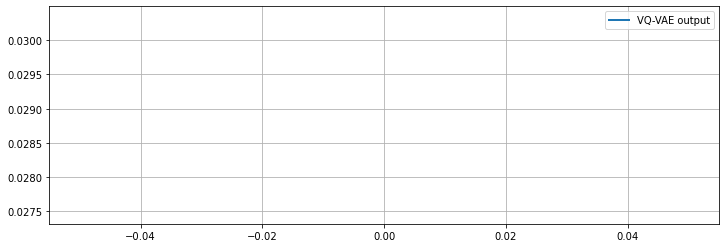

In [402]:
model.eval()

batch = next(iter(test_loader))

x = batch["x"].to(device)
y = batch["y"].to(device)

with torch.no_grad():
    y_hat = model(x)

idx = 0


clean = y[idx, 0].cpu().numpy()
noisy = x[idx, 0].cpu().numpy()
pred = y_hat[idx, 0].cpu().numpy()

plt.figure(figsize=(12, 4))
#plt.plot(noisy, label="noisy input", alpha=0.6)
#plt.plot(clean, label="clean target", linewidth=2)
plt.plot(pred, label="VQ-VAE output", linewidth=2)
plt.legend()
plt.grid(True)
plt.show()